# The 3-Qubit Repetition Code

This notebook reviews the 3-qubit repetition code, one of the most basic quantum error correction algorithms. We will see how the syndrome identifies a single bit-flip error and why the code fails against phase flips. Logical failure will depend on the physical bit-flip rate. The tutorial builds the code for understanding these ideas, from deriving a syndrome table to simulating noisy runs and measuring decoding success rates versus physical error rates.

In [15]:
# Import Dependencies 
import numpy as np
import matplotlib.pyplot as plt
from itertools import product as iproduct

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error
from qiskit.quantum_info import Statevector

sim = AerSimulator()

### 1. Logical encoding

We define the \textbf{logical} basis states as:

$$\ket{0_L} = \ket{000}, \quad \ket{1_L} = \ket{111}$$

An arbitrary logical qubit can be written as:

$$\ket{\psi} = \alpha \ket{0} + \beta \ket{1}$$

and encoded in the logical basis a:

$$\ket{\psi_L} = \alpha \ket{000} + \beta \ket{111} $$

The redundancy in the encoding lets us later detect disagreement between neighboring qubit states without revealing the logical information $\alpha, \beta$.

In [16]:
def encode_logical_bit(bit: int) -> list[int]:
    """Encode a classical logical bit into the 3-bit repetition code."""
    assert bit in (0, 1), "bit must be 0 or 1"
    return [bit, bit, bit]

print("Logical 0 ->", encode_logical_bit(0))
print("Logical 1 ->", encode_logical_bit(1))

Logical 0 -> [0, 0, 0]
Logical 1 -> [1, 1, 1]


### 1.1  Encoding Circuit

The quantum encoding is implemented with two CNOT gates from the data qubit $q_0$ onto the ancilla qubits $q_1$ and $q_2$:

$$|\psi\rangle|00\rangle \xrightarrow{\text{CNOT}_{01}} \xrightarrow{\text{CNOT}_{02}} |\psi_L\rangle$$

The state $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$ on $q_0$ fans out into the three-qubit codeword.

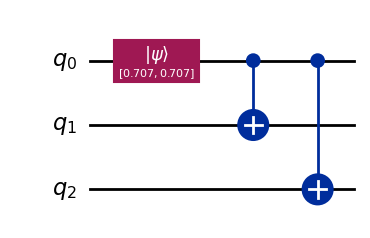

In [17]:
def build_encoding_circuit(alpha: complex = 1.0, beta: complex = 0.0) -> QuantumCircuit:
    """
    Build the 3-qubit repetition code encoding circuit.
    alpha|0> + beta|1>  ->  alpha|000> + beta|111>
    """
    norm = np.sqrt(abs(alpha)**2 + abs(beta)**2)
    alpha, beta = alpha / norm, beta / norm

    qc = QuantumCircuit(3, name="encode")
    # Initialise q0 to the desired logical state
    qc.initialize([alpha, beta], 0)
    # Fan-out
    qc.cx(0, 1)
    qc.cx(0, 2)
    return qc

enc = build_encoding_circuit(alpha=1/np.sqrt(2), beta=1/np.sqrt(2))
enc.draw("mpl")

In [18]:
# Verify: for |0_L> the only non-zero amplitude should be |000>

def fmt_complex(z: complex) -> str:
    """Format a complex amplitude as 'a+bj' rounded to 4 dp."""
    r, i = round(z.real, 4), round(z.imag, 4)
    return f"{r}" if i == 0 else f"{r}+{i}j" if i > 0 else f"{r}{i}j"

def print_sv(label: str, qc: QuantumCircuit) -> None:
    sv = Statevector(qc)
    nonzero = {k: fmt_complex(v) for k, v in sv.to_dict().items() if abs(v) > 1e-9}
    print(f"{label}: {nonzero}")

print_sv("State vector for |0_L>", build_encoding_circuit(alpha=1, beta=0))
print_sv("State vector for |1_L>", build_encoding_circuit(alpha=0, beta=1))
print_sv("State vector for |+_L>", build_encoding_circuit(alpha=1/np.sqrt(2), beta=1/np.sqrt(2)))


State vector for |0_L>: {np.str_('000'): '1.0'}
State vector for |1_L>: {np.str_('111'): '1.0'}
State vector for |+_L>: {np.str_('000'): '0.7071', np.str_('111'): '0.7071'}


### Error Model

To simulate random errors that flip a given qubit, we will build a function that applies a random bit flip to the 3-bit classical string or simulated quantum state. For this introduction, the classical bit flip willl be sufficient to highlight the mechanism of the error detection algorithm.

The noise funciton will include the following:
* Each qubit will be independently affected by a random bit flip error, captured by an $X$-gate, which is applied with probability $p$.
* One round of syndrom extraction is used

We simulate depolarising bit-flip noise using Qiskit Aer's `NoiseModel`. Each data qubit independently suffers an $X$ error with probability $p$ after encoding. This is a simplified channel:

$$\mathcal{E}(\rho) = (1-p)\rho + p\, X\rho X$$

One round of syndrome extraction follows the noisy data layer. We ignore measurement errors and ancilla noise for clarity. These are important in realistic codes but would obscure the core mechanism here.

In [19]:
def build_noise_model(p: float) -> NoiseModel:
    """Single-qubit bit-flip channel with probability p on every CX gate target."""
    nm = NoiseModel()
    bit_flip = pauli_error([("X", p), ("I", 1 - p)])
    # Apply after every single-qubit gate on the data qubits
    nm.add_all_qubit_quantum_error(bit_flip, ["id", "x"])
    return nm

print("Noise model for p=0.1:")
print(build_noise_model(0.1))

Noise model for p=0.1:
NoiseModel:
  Basis gates: ['cx', 'id', 'rz', 'sx', 'x']
  Instructions with noise: ['x', 'id']
  All-qubits errors: ['id', 'x']


### Stabilizers and syndrome extraction

Here, let us introduce the followin stabilizers:

$S_1 = Z_1Z_1, \quad S_2 = Z_2Z_3$

The code states $\ket{000}$ and $\ket{111}$ are $+1$ eigenstates of both stabilizers. An $X$ error on qubit $i$ anti-commutes with any $Z$ acting on $i$, flipping the eigenvalue to $-1$ and producing a detectable **syndrome**.

### Syndrome table

| Error | $s_1 = \langle S_1 \rangle$ | $s_2 = \langle S_2 \rangle$ | Syndrome $(s_1, s_2)$ |
|-------|------|------|--------|
| None  | +1   | +1   | (0, 0) |
| $X_1$ | -1   | +1   | (1, 0) |
| $X_2$ | -1   | -1   | (1, 1) |
| $X_3$ | +1   | -1   | (0, 1) |

Here we encode the syndrome bit as $0$ for eigenvalue $+1$ and $1$ for $-1$.

### 3.1  Syndrome Extraction Circuit

Syndrome extraction uses two ancilla qubits ($a_0, a_1$) which are prepared in $\ket{+}$ to measure the stabilizers non-destructively:

- $a_0$ measures $Z_1 Z_2$ via controlled-$Z$ interactions
- $a_1$ measures $Z_2 Z_3$

In the $X$-basis picture this translates to CNOT gates from the data qubits onto the ancilla:

$$a_0: \quad \text{CNOT}(q_0 \to a_0),\; \text{CNOT}(q_1 \to a_0)$$
$$a_1: \quad \text{CNOT}(q_1 \to a_1),\; \text{CNOT}(q_2 \to a_1)$$

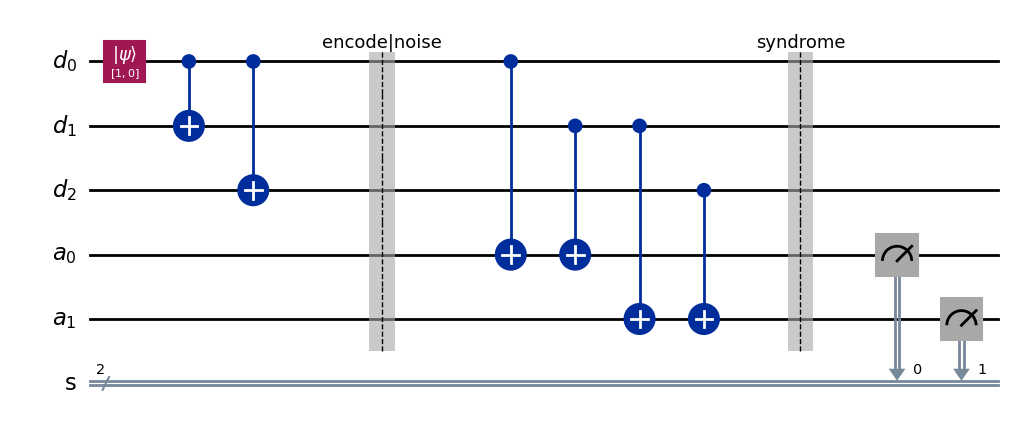

In [20]:
def build_syndrome_circuit(alpha: complex = 1.0, beta: complex = 0.0) -> QuantumCircuit:
    """
    Full encode + syndrome extraction circuit.
    Returns a QuantumCircuit with:
      q[0..2]  : data qubits
      q[3..4]  : ancilla qubits (syndrome)
      c[0..1]  : classical syndrome bits
    """
    data = QuantumRegister(3, "d")
    anc  = QuantumRegister(2, "a")
    syn  = ClassicalRegister(2, "s")

    qc = QuantumCircuit(data, anc, syn)

    # --- Encoding ---
    norm = np.sqrt(abs(alpha)**2 + abs(beta)**2)
    qc.initialize([alpha / norm, beta / norm], data[0])
    qc.cx(data[0], data[1])
    qc.cx(data[0], data[2])

    qc.barrier(label="encode|noise")

    # --- Syndrome extraction ---
    # Measure S1 = Z0 Z1
    qc.cx(data[0], anc[0])
    qc.cx(data[1], anc[0])
    # Measure S2 = Z1 Z2
    qc.cx(data[1], anc[1])
    qc.cx(data[2], anc[1])

    qc.barrier(label="syndrome")
    qc.measure(anc[0], syn[0])
    qc.measure(anc[1], syn[1])

    return qc

qc_syn = build_syndrome_circuit(alpha=1, beta=0)
qc_syn.draw("mpl", fold=-1)

### 3.2  Classical Syndrome Table

Before running noisy simulations, let's verify the syndrome table analytically using the classical parity picture.

In [21]:
def measure_syndrome(codeword: list[int]) -> tuple[int, int]:
    """
    Compute syndrome bits from a (possibly corrupted) 3-bit codeword.
    s1 = q0 XOR q1  (detects disagreement between qubits 0 and 1)
    s2 = q1 XOR q2  (detects disagreement between qubits 1 and 2)
    Returns (s1, s2) where 0 = no error detected, 1 = error detected.
    """
    s1 = codeword[0] ^ codeword[1]
    s2 = codeword[1] ^ codeword[2]
    return (s1, s2)

# Build the syndrome table for all single-qubit bit-flip errors
codeword_0 = [0, 0, 0]
errors = {
    "None":  [0, 0, 0],
    "X on q0": [1, 0, 0],
    "X on q1": [0, 1, 0],
    "X on q2": [0, 0, 1],
}

print(f"{'Error':<12} {'Corrupted codeword':<22} {'Syndrome (s1,s2)'}")
print("-" * 55)
for label, err in errors.items():
    corrupted = [c ^ e for c, e in zip(codeword_0, err)]
    syn = measure_syndrome(corrupted)
    print(f"{label:<12} {str(corrupted):<22} {syn}")

Error        Corrupted codeword     Syndrome (s1,s2)
-------------------------------------------------------
None         [0, 0, 0]              (0, 0)
X on q0      [1, 0, 0]              (1, 0)
X on q1      [0, 1, 0]              (1, 1)
X on q2      [0, 0, 1]              (0, 1)


## 4  Decoding

Given the syndrome $(s_1, s_2)$, the **minimum-weight decoder** applies the unique correction that maps the syndrome back to $(0,0)$:

| Syndrome | Correction |
|----------|------------|
| (0, 0)   | $I$ (none) |
| (1, 0)   | $X_0$      |
| (1, 1)   | $X_1$      |
| (0, 1)   | $X_2$      |

This is also the **majority-vote** decoder: output the bit value held by at least 2 of the 3 qubits.

In [22]:
# Syndrome -> (qubit to correct, or None)
SYNDROME_CORRECTION = {
    (0, 0): None,
    (1, 0): 0,
    (1, 1): 1,
    (0, 1): 2,
}

def decode(codeword: list[int]) -> int:
    """
    Decode a (possibly corrupted) 3-bit codeword using minimum-weight decoding.
    Returns the decoded logical bit (0 or 1).
    """
    syn = measure_syndrome(codeword)
    correction_qubit = SYNDROME_CORRECTION.get(syn)
    corrected = list(codeword)
    if correction_qubit is not None:
        corrected[correction_qubit] ^= 1   # flip the identified qubit
    # Majority vote on the corrected word
    return int(sum(corrected) > 1)


# Sanity check: all single-qubit errors should be corrected
for logical in [0, 1]:
    cw = encode_logical_bit(logical)
    for i in range(3):
        corrupted = list(cw)
        corrupted[i] ^= 1
        recovered = decode(corrupted)
        status = "success" if recovered == logical else "failure"
        print(f"{status}  logical={logical}, X on q{i}: {cw} -> {corrupted} -> decoded={recovered}")

success  logical=0, X on q0: [0, 0, 0] -> [1, 0, 0] -> decoded=0
success  logical=0, X on q1: [0, 0, 0] -> [0, 1, 0] -> decoded=0
success  logical=0, X on q2: [0, 0, 0] -> [0, 0, 1] -> decoded=0
success  logical=1, X on q0: [1, 1, 1] -> [0, 1, 1] -> decoded=1
success  logical=1, X on q1: [1, 1, 1] -> [1, 0, 1] -> decoded=1
success  logical=1, X on q2: [1, 1, 1] -> [1, 1, 0] -> decoded=1


## 5  Logical Error Rate vs Physical Error Rate

The code corrects any **single** bit-flip but fails when **two or more** qubits are flipped simultaneously. The logical failure probability for independent bit-flip rate $p$ is:

$$p_L = \binom{3}{2}p^2(1-p) + \binom{3}{3}p^3 = 3p^2 - 2p^3$$

The break-even point $p_L = p$ occurs at $p^* = 1/2$. Below this threshold, encoding is beneficial.


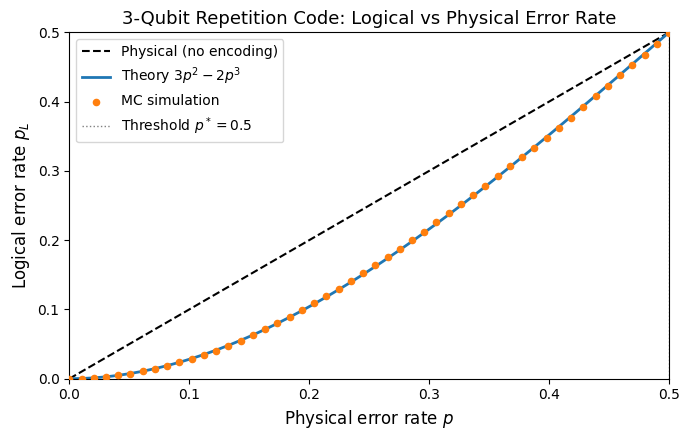

In [23]:
def simulate_logical_error_rate(p: float, n_shots: int = 50_000, logical_bit: int = 0) -> float:
    """
    Monte Carlo estimate of the logical error rate for the 3-qubit repetition code
    at physical bit-flip rate p.
    """
    rng = np.random.default_rng(seed=42)
    codeword = encode_logical_bit(logical_bit)
    failures = 0

    # Vectorised: shape (n_shots, 3), True where a bit flip occurs
    flips = rng.random((n_shots, 3)) < p
    corrupted = (np.array(codeword) ^ flips.astype(int))  # XOR row-wise

    for row in corrupted:
        decoded = decode(list(row))
        if decoded != logical_bit:
            failures += 1

    return failures / n_shots


# Sweep physical error rates
p_vals = np.linspace(0, 0.5, 50)
p_L_sim   = [simulate_logical_error_rate(p) for p in p_vals]
p_L_theory = 3 * p_vals**2 - 2 * p_vals**3

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(p_vals, p_vals,      "k--",  label="Physical (no encoding)",  lw=1.5)
ax.plot(p_vals, p_L_theory,  "C0-",  label="Theory $3p^2 - 2p^3$",   lw=2)
ax.scatter(p_vals, p_L_sim,  c="C1", s=20, zorder=3, label="MC simulation")
ax.axvline(0.5, color="grey", ls=":", lw=1, label="Threshold $p^*=0.5$")
ax.set_xlabel("Physical error rate $p$", fontsize=12)
ax.set_ylabel("Logical error rate $p_L$", fontsize=12)
ax.set_title("3-Qubit Repetition Code: Logical vs Physical Error Rate", fontsize=13)
ax.legend()
ax.set_xlim(0, 0.5)
ax.set_ylim(0, 0.5)
plt.tight_layout()
plt.show()

## 6  Why the Code Fails Against Phase Flips

The repetition code is designed exclusively for bit-flip ($X$) errors. A **phase flip** ($Z$) error acts as:

$$Z|000\rangle = |000\rangle, \quad Z_0\big(\alpha|000\rangle + \beta|111\rangle\big) = \alpha|000\rangle - \beta|111\rangle$$

This flips the relative phase between $|0_L\rangle$ and $|1_L\rangle$, implementing a logical $\bar{Z}$ error. Crucially, a phase flip on **any** of the three data qubits produces the same effect — the syndrome $(s_1, s_2)$ remains $(0,0)$ because $Z$ commutes with both stabilizers $Z_1Z_2$ and $Z_2Z_3$. The code is **blind** to phase errors.

To handle both $X$ and $Z$ errors simultaneously, one must use a CSS code such as the **Shor code** (a concatenation of the 3-qubit bit-flip and 3-qubit phase-flip codes) or, ultimately, the **surface code**.

In [24]:
# Demonstrate that a Z error is invisible to the syndrome
# We use the statevector to inspect phases directly

qc_no_error = build_encoding_circuit(alpha=1/np.sqrt(2), beta=1/np.sqrt(2))
sv_clean    = Statevector(qc_no_error)

qc_z_error  = build_encoding_circuit(alpha=1/np.sqrt(2), beta=1/np.sqrt(2))
qc_z_error.z(0)   # apply Z to qubit 0 after encoding
sv_z        = Statevector(qc_z_error)

print("Amplitudes WITHOUT phase error:")
for k, v in sv_clean.to_dict().items():
    if abs(v) > 1e-9:
        print(f"  |{k}> : {v:.4f}")

print("\nAmplitudes WITH Z error on q0:")
for k, v in sv_z.to_dict().items():
    if abs(v) > 1e-9:
        print(f"  |{k}> : {v:.4f}")

print("\nClassical syndrome (based on bit values only):")
# Classical syndrome cannot distinguish these — the bit values are the same
cw = [0, 0, 0]   # both states have the same population on |000> and |111>
print(f"  syndrome = {measure_syndrome(cw)}  <- identical for both states")

Amplitudes WITHOUT phase error:
  |000> : 0.7071+0.0000j
  |111> : 0.7071+0.0000j

Amplitudes WITH Z error on q0:
  |000> : 0.7071+0.0000j
  |111> : -0.7071+0.0000j

Classical syndrome (based on bit values only):
  syndrome = (0, 0)  <- identical for both states
